# Réalisation du plan d'expérience de l'algorithme du Plus Proche Voisin (Nearest Neighbor)

Ce plan d'expérience suivra ce plan : 
- Définition des paramètres globaux
- Étude de trajectoire
- Étude de l'influence des paramètres
- Définition des paramètres optimisés

## Définition des paramètres globaux

Nous allons réaliser l'étude statistique sur les paramètres suivants:
- $N= \{10, 12, 15, 17, 20, 22, 25, 30\}$ : nombre de sommets
- `multi_start` $\in \{\text{True}, \text{False}\}$ : paramètre principal de l'algorithme
  - `True` : l'algorithme est lancé depuis **chaque sommet** du graphe, et le meilleur résultat est conservé
  - `False` : l'algorithme est lancé depuis **un seul sommet aléatoire** sans contrainte de précédence

L'objectif est d'itérer sur les mêmes graphes. Nous utilisons donc des `seed` pour chaque instance de graphe $N$.
Nous allons ensuite calculer la borne de chaque graphe. Cela nous permettra de calculer le `gap` pour comparer équitablement les algorithmes entre eux.

### Résultats

Chaque algorithme doit avoir en sortie: 
- le meilleur coût des itérations
- la moyenne des coûts
- la médiane des coûts
- l'écart-type
- le minimum et le maximum
- graphiques:
    - Trajectoire (accumulation du coût au fil des nœuds visités)
    - Influence de chaque paramètre (Heatmap à double entrée (type github)) → tendance générale
    - Distance à la borne (`gap`)
- Meilleurs paramètres

In [85]:
import sys

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

sys.path.insert(0, "../../")
sys.path.insert(0, "../")

from graph_generator import generate_graph
from src.algorithms.ant_system import resolve_by_ant_system


### Paramètres globaux et génération des instances

- `N_VALUES` : tailles de graphe étudiées
- `NB_SEEDS` : nombre d'instances (seed distinct) par taille — pour itérer sur les mêmes graphes
- `NB_ITERATIONS` : nombre d'itérations de l'algorithme par instance

In [86]:
N_VALUES: list[int] = [10, 12, 15, 17, 20, 22, 25, 30]
NB_SEEDS: int = 25
NB_ITERATIONS: int = 300


def get_standard_instances(n: int, nb_seeds: int = NB_SEEDS) -> list[tuple[int, nx.Graph]]:
    """Génère `nb_seeds` graphes reproductibles de taille `n`, un par seed."""
    instances: list[tuple[int, nx.Graph]] = []
    for seed in range(nb_seeds):
        np.random.seed(seed)
        graph = generate_graph(n)
        instances.append((seed, graph))
    return instances


### Borne de référence et gap

Borne inférieure « min-sortants » pour toutes les tailles : $\frac{1}{2} \sum_v \min_{u \neq v} w(v,u)$, arêtes interdites ($w = -1$) exclues.

$$\text{gap} = 100 \times \frac{\text{cost} - \text{reference}}{\text{reference}}$$

In [87]:
def lower_bound_min_outgoing(graph: nx.Graph) -> float:
    """Borne inférieure : demi-somme des arêtes sortantes minimales (arêtes interdites exclues)."""
    total: float = 0.0
    for v in graph.nodes():
        min_edge: float = float("inf")
        for u in graph.nodes():
            if u == v:
                continue
            w: float = graph.edges[v, u]["weight"]
            if w == -1:
                continue
            if w < min_edge:
                min_edge = w
        if min_edge != float("inf"):
            total += min_edge
    return total / 2.0


def reference_value(graph: nx.Graph) -> float:
    """Borne inférieure de référence pour le calcul du gap."""
    return lower_bound_min_outgoing(graph)


def compute_gap(cost: float, reference: float) -> float:
    """Gap en %, NaN si `reference <= 0`."""
    if reference <= 0:
        return float("nan")
    return 100.0 * (cost - reference) / reference


### Pré-calcul des instances et bornes

On matérialise `instances[n]` = liste de `(seed, graph, reference)` pour réutiliser les mêmes graphes + bornes dans toutes les études suivantes.

In [88]:
instances: dict[int, list[tuple[int, nx.Graph, float]]] = {}

for n in N_VALUES:
    raw: list[tuple[int, nx.Graph]] = get_standard_instances(n)
    enriched: list[tuple[int, nx.Graph, float]] = []
    for seed, graph in raw:
        ref: float = reference_value(graph)
        enriched.append((seed, graph, ref))
    instances[n] = enriched
    refs: list[float] = [r for _, _, r in enriched]
    print(f"N={n:3d} | {len(enriched)} instances | ref min={min(refs):.2f} max={max(refs):.2f}")

N= 10 | 25 instances | ref min=5.10 max=18.52
N= 12 | 25 instances | ref min=2.25 max=20.10
N= 15 | 25 instances | ref min=4.50 max=17.62
N= 17 | 25 instances | ref min=6.90 max=16.80
N= 20 | 25 instances | ref min=7.58 max=16.87
N= 22 | 25 instances | ref min=5.40 max=16.87
N= 25 | 25 instances | ref min=6.38 max=18.60
N= 30 | 25 instances | ref min=7.65 max=14.02


## Étude de trajectoire

On observe la convergence du **meilleur coût** en fonction du nombre d'itérations ACO sur une instance de référence (`N=20`, `seed=0`), avec les paramètres par défaut de `resolve_by_ant_system`.

Implémentation : on appelle l'algorithme avec un seed `numpy` fixé pour `n_iterations` croissant de 1 à `NB_ITERATIONS`. Le RNG étant déterministe, le run à `k` itérations partage ses `k-1` premières itérations avec le run à `k-1` — la valeur finale de chaque run donne donc le meilleur coût après `k` itérations d'un unique processus stochastique.

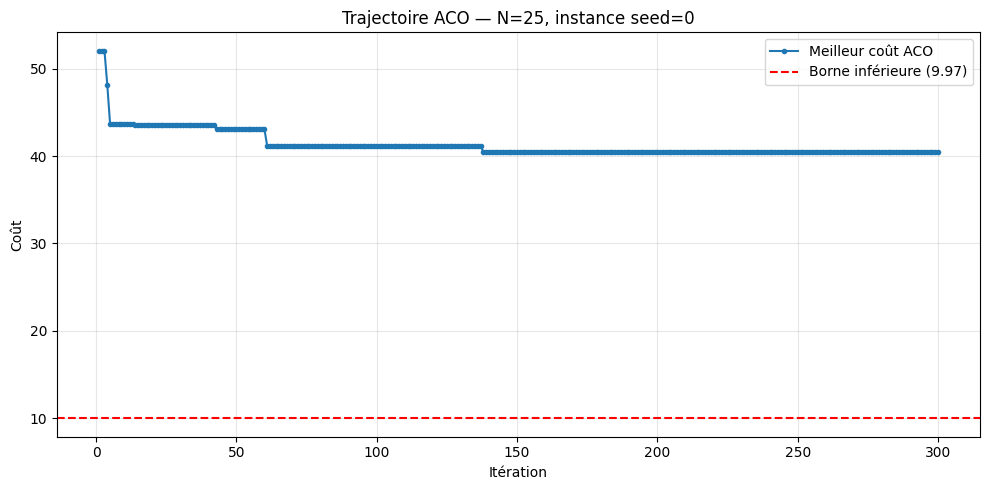

Coût final : 40.50 | gap vs borne : 306.02%


In [89]:
ALGO_SEED: int = 42

DEFAULT_PARAMS: dict = {
    "alpha": 1.0,
    "beta": 5.0,
    "evaporation_rate": 0.5,
    "initial_pheromone": 1.0,
}


def run_algo(graph: nx.Graph, n_iterations: int, seed: int, **params) -> tuple[list[int], float]:
    """Exécute resolve_by_ant_system avec seed numpy fixé pour reproductibilité."""
    np.random.seed(seed)
    return resolve_by_ant_system(graph, n_iterations=n_iterations, **params)


def trajectory(graph: nx.Graph, n_iterations: int, seed: int, **params) -> list[float]:
    """Meilleur coût après k=1..n_iterations. Coût inf si aucune tournée faisable."""
    history: list[float] = []
    for k in range(1, n_iterations + 1):
        _, cost = run_algo(graph, n_iterations=k, seed=seed, **params)
        history.append(cost)
    return history


TRAJECTORY_N: int = 25
TRAJECTORY_SEED: int = 0

traj_graph: nx.Graph = [g for s, g, r in instances[TRAJECTORY_N] if s == TRAJECTORY_SEED][0]
traj_ref: float = [r for s, _, r in instances[TRAJECTORY_N] if s == TRAJECTORY_SEED][0]

history: list[float] = trajectory(
    traj_graph,
    n_iterations=NB_ITERATIONS,
    seed=ALGO_SEED,
    **DEFAULT_PARAMS,
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, NB_ITERATIONS + 1), history, marker="o", markersize=3, label="Meilleur coût ACO")
ax.axhline(traj_ref, color="red", linestyle="--", label=f"Borne inférieure ({traj_ref:.2f})")
ax.set_xlabel("Itération")
ax.set_ylabel("Coût")
ax.set_title(f"Trajectoire ACO — N={TRAJECTORY_N}, instance seed={TRAJECTORY_SEED}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

final_cost: float = history[-1]
final_gap: float = compute_gap(final_cost, traj_ref)
print(f"Coût final : {final_cost:.2f} | gap vs borne : {final_gap:.2f}%")

## Étude de l'influence des paramètres

Afin de comprendre l'influence de l'algorithme, on va effectuer une recherche en grille (Grid Search) sur deux paramètres majeurs de l'algorithme des colonies de fourmis :
- $\alpha$ (importance de la trace de phéromone)
- $\beta$ (importance de la visibilité / heuristique gloutonne)
- `evaporation_rate` (décide du taux d'évaporation des phéromones)
- `initial_pheromone` (taux de phéromones par défaut)

Nous allons afficher une "Heatmap" pour visualiser la tendance générale.

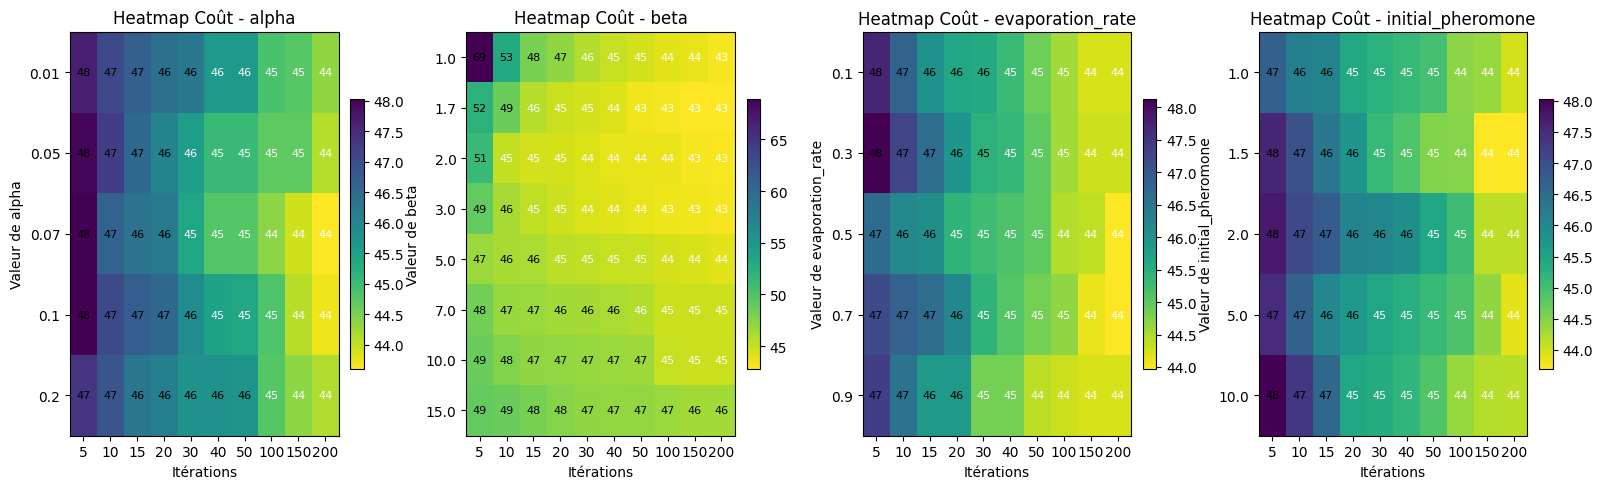

Meilleurs paramètres trouvés pour N=20 :
  - alpha = 0.07
  - beta = 1.7
  - evaporation_rate = 0.5
  - initial_pheromone = 1.5


In [92]:
import matplotlib.pyplot as plt

TUNING_N: int = 20
tuning_instances = instances[TUNING_N][:10] # 3 instances pour lisser
tuning_iterations = [5, 10, 15, 20, 30, 40, 50, 100, 150, 200]

param_grids = {
    "alpha": [0.01, 0.05, 0.07, 0.1, 0.2],
    "beta": [1.0, 1.7, 2.0, 3.0, 5.0, 7.0, 10.0, 15.0],
    "evaporation_rate": [0.1, 0.3, 0.5, 0.7, 0.9],
    "initial_pheromone": [1.0, 1.5, 2.0, 5.0, 10.0]
}

best_params_found = DEFAULT_PARAMS.copy()

fig, axes = plt.subplots(1, len(param_grids), figsize=(16, 5))

for idx, (param_name, param_values) in enumerate(param_grids.items()):
    # result_matrix: lignes = valeurs du paramètre, colonnes = itérations
    result_matrix = np.zeros((len(param_values), len(tuning_iterations)))

    for i, val in enumerate(param_values):
        for j, n_iter in enumerate(tuning_iterations):
            avg_cost = 0.0

            for seed, graph, ref in tuning_instances:
                # On utilise les paramètres par défaut, mais on remplace le paramètre en cours d'étude
                current_params = DEFAULT_PARAMS.copy()
                current_params[param_name] = val

                _, cost = run_algo(
                    graph,
                    n_iterations=n_iter,
                    seed=ALGO_SEED,
                    **current_params
                )
                avg_cost += cost

            result_matrix[i, j] = avg_cost / len(tuning_instances)

    # Trouver le meilleur paramètre globalement pour ce paramètre (celui qui donne le coût minimal à la fin)
    best_val_idx = np.argmin(result_matrix[:, -1])
    best_params_found[param_name] = param_values[best_val_idx]

    # Affichage de la Heatmap
    ax = axes[idx]
    cax = ax.matshow(result_matrix, cmap="viridis_r", aspect="auto")

    # Annotations
    for i in range(len(param_values)):
        for j in range(len(tuning_iterations)):
            val_cost = result_matrix[i, j]
            color = "w" if val_cost < result_matrix.mean() else "k"
            ax.text(j, i, f"{val_cost:.0f}", ha="center", va="center", color=color, fontsize=8)

    ax.set_xticks(range(len(tuning_iterations)))
    ax.set_xticklabels(tuning_iterations)
    ax.set_yticks(range(len(param_values)))
    ax.set_yticklabels(param_values)
    ax.xaxis.set_ticks_position('bottom')
    ax.set_xlabel("Itérations")
    ax.set_ylabel(f"Valeur de {param_name}")
    ax.set_title(f"Heatmap Coût - {param_name}")
    fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

BEST_ALPHA = best_params_found["alpha"]
BEST_BETA = best_params_found["beta"]
print(f"Meilleurs paramètres trouvés pour N={TUNING_N} :")
for k, v in best_params_found.items():
    print(f"  - {k} = {v}")


## Définition des paramètres optimisés

Nous utilisons les paramètres optimisés identifiés lors du tuning pour évaluer de manière exhaustive l'algorithme sur l'ensemble de nos instances. Le calcul va s'effectuer systématiquement pour toutes les tailles définies au début afin de collecter :

- le meilleur coût, la moyenne, médiane, écart-type, minimum et maximum
- Distance à la borne (gap) pour comparer de manière équitable

,Meilleur_Coût_Min,Pire_Coût_Max,Moyenne,Médiane,Ecart_type,Gap_Moyen_pct
N,,,,,,
10,24.60,51.90,38.97,39.00,7.69,290.23
12,20.55,71.95,41.07,38.40,11.75,311.97
15,29.25,60.30,42.45,41.70,9.19,320.46
17,29.70,65.25,43.59,42.05,9.27,317.77
20,31.65,68.40,47.93,47.90,9.26,333.08
22,22.05,70.95,47.22,45.45,11.04,336.37
25,31.20,76.40,53.19,53.55,9.73,371.02
30,42.15,73.35,54.31,54.45,7.97,405.89


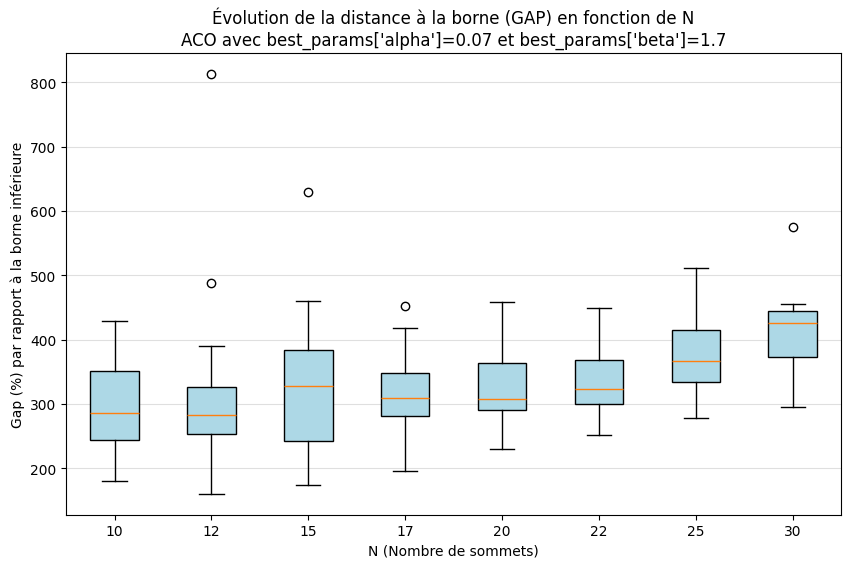

In [93]:
# Lancement sur le grand dataset avec les "meilleures" variables d'influence ajustées.
# D'après la Heatmap et nos optimisations.
best_params = DEFAULT_PARAMS.copy()
best_params["alpha"] = BEST_ALPHA
best_params["beta"] = BEST_BETA

results_list: list[dict] = []
for n, n_instances in instances.items():
    for seed, graph, ref in n_instances:
        _, cost = run_algo(graph, n_iterations=NB_ITERATIONS, seed=ALGO_SEED, **best_params)
        gap = compute_gap(cost, ref) if ref > 0 else float("inf")
        results_list.append({
            "N": n,
            "cost": cost,
            "gap": gap
        })

df_all = pd.DataFrame(results_list)

# Calcul des statistiques via pandas groupby
stats_df = df_all.groupby("N").agg(
    Meilleur_Coût_Min=("cost", "min"),
    Pire_Coût_Max=("cost", "max"),
    Moyenne=("cost", "mean"),
    Médiane=("cost", "median"),
    Ecart_type=("cost", "std"),
    Gap_Moyen_pct=("gap", "mean")
)

display(stats_df.round(2))

# Affichage visuel (Gap à la borne inférieure) avec matplotlib seul
plt.figure(figsize=(10, 6))

boxplot_data = [group["gap"].values for name, group in df_all.groupby("N")]
n_labels = [name for name, group in df_all.groupby("N")]

bp = plt.boxplot(boxplot_data, patch_artist=True)
for box in bp['boxes']:
    # change box color
    box.set(facecolor='lightblue')

plt.xticks(range(1, len(n_labels) + 1), n_labels)
plt.title(f"Évolution de la distance à la borne (GAP) en fonction de N\nACO avec {best_params['alpha']=} et {best_params['beta']=}")
plt.xlabel("N (Nombre de sommets)")
plt.ylabel("Gap (%) par rapport à la borne inférieure")
plt.grid(alpha=0.4, axis='y')
plt.show()